In [10]:
# nltk
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
!pip install spacy

  Using cached spacy-3.8.14-cp312-cp312-win_amd64.whl.metadata (28 kB)
Using cached spacy-3.8.14-cp312-cp312-win_amd64.whl (14.2 MB)


ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'C:\\Python312\\Scripts\\spacy.exe' -> 'C:\\Python312\\Scripts\\spacy.exe.deleteme'


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [54]:
!pip install tf-keras

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 1.2 MB/s eta 0:00:01
   ------------------ --------------------- 0.8/1.7 MB 1.2 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 1.3 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 1.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 1.3 MB/s  0:00:01
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 1.2 MB/s eta 0:04:53
   ---------------------------------------- 0.8/350.9 MB 1.2 MB/s eta 0:05:03
   ---------------------------------------- 1.0

  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 2] The system cannot find the file specified: 'C:\\Python312\\Scripts\\saved_model_cli.exe' -> 'C:\\Python312\\Scripts\\saved_model_cli.exe.deleteme'


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
!pip install sentence-transformers

   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.9 kB ? eta -:--:--
   ----------------- ---------------------- 262.1/588.9 kB ? eta -:--:--
   ---------------------------------------- 588.9/588.9 kB 774.3 kB/s  0:00:00



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
# import necessary libraries
import spacy
import pandas as pd

# import visualization tools
import seaborn as sns
import matplotlib.pyplot as plt

# import nlp tools
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

In [45]:
# constants
REQUIRED_COLS = [
    'tweet_id', 'author_id', 'inbound', 'created_at',
    'text', 'response_tweet_id', 'in_response_to_tweet_id'
]

COMPLAINT_KW = [
    'not working', 'broken', 'error', 'issue', 'problem', 'fail', 'failed',
    'terrible', 'awful', 'horrible', 'worst', 'disappointed', 'frustrated',
    'useless', 'wrong', 'bad', 'hate', 'ridiculous', 'unacceptable',
    'outraged', 'fix this', 'still not', 'never works', 'pathetic'
]

POSITIVE_KW = [
    'thank', 'thanks', 'great job', 'love this', 'awesome', 'excellent',
    'amazing', 'wonderful', 'fantastic', 'good job', 'well done',
    'appreciate', 'perfect'
]

# knowledge base for RAG
KNOWLEDGE_BASE = [
    "Refunds are available within 30 days.",
    "Password reset can be completed from account settings.",
    "Shipping usually takes 5 business days.",
    "Premium users receive priority support."
]

In [3]:
# load dataset
df = pd.read_csv('dataset/twcs.csv')

# display first 5 rows
df.head()

,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


In [4]:
# show columns
print(f'\nColumns: {df.columns.tolist()}')

print('=======================================')

# show data type of each column
print(f'\nDtypes:\n{df.dtypes}')

print('=======================================')

# check dataset shape
print('Dataset shape:', df.shape)

print('=======================================')

# check missing values
print('Missing values per column')
print(df.isnull().sum())


Columns: ['tweet_id', 'author_id', 'inbound', 'created_at', 'text', 'response_tweet_id', 'in_response_to_tweet_id']

Dtypes:
tweet_id                     int64
author_id                   object
inbound                       bool
created_at                  object
text                        object
response_tweet_id           object
in_response_to_tweet_id    float64
dtype: object
Dataset shape: (2811774, 7)
Missing values per column
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64


In [5]:
missing = [c for c in REQUIRED_COLS if c not in df.columns]
if missing:
    raise ValueError(f'Missing expected columns: {missing}')

print('All required columns present.')
print(f'\nNull counts:\n{df[REQUIRED_COLS].isnull().sum()}')

All required columns present.

Null counts:
tweet_id                         0
author_id                        0
inbound                          0
created_at                       0
text                             0
response_tweet_id          1040629
in_response_to_tweet_id     794335
dtype: int64


In [7]:
# normalize inbound flag
df['inbound'] = (
    df['inbound'].astype(str).str.strip()
    .map({'True': True, 'False': False, '1': True, '0': False})
)
df = df.dropna(subset=['inbound'])
df['inbound'] = df['inbound'].astype(bool)

# show customer responses
print(f'Inbound (customer) tweets : {df["inbound"].sum():,}')
# show company responses
print(f'Outbound (company) tweets : {(~df["inbound"]).sum():,}')

Inbound (customer) tweets : 1,537,843
Outbound (company) tweets : 1,273,931


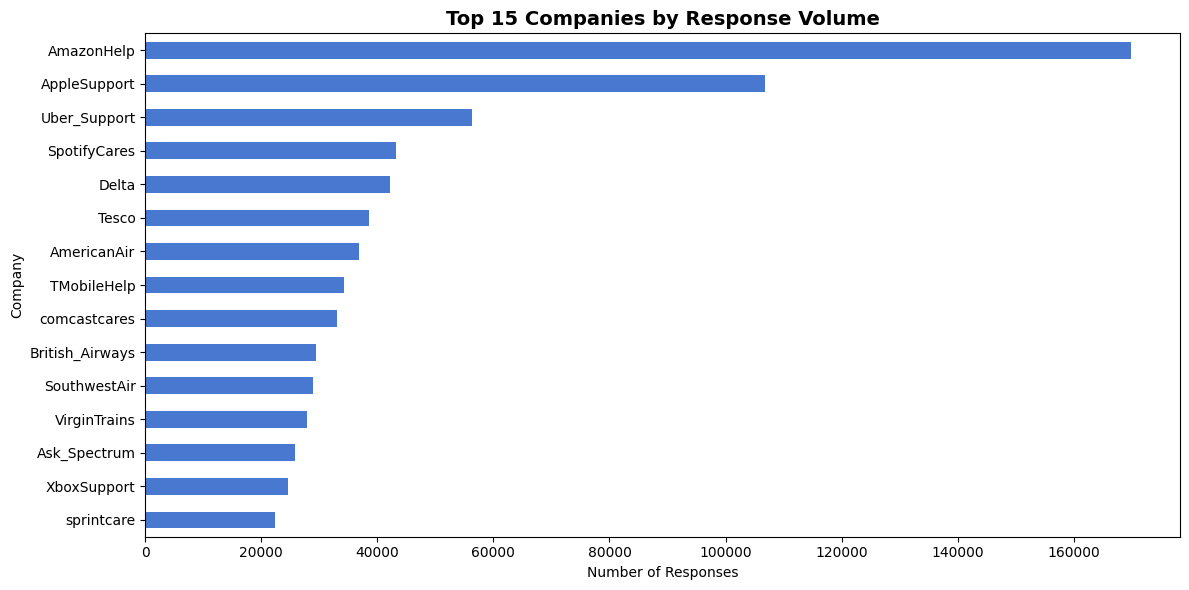

author_id
AmazonHelp         169840
AppleSupport       106860
Uber_Support        56270
SpotifyCares        43265
Delta               42253
Tesco               38573
AmericanAir         36764
TMobileHelp         34317
comcastcares        33031
British_Airways     29361
SouthwestAir        28977
VirginTrains        27817
Ask_Spectrum        25860
XboxSupport         24557
sprintcare          22381


In [8]:
# show total responses by different companies in the dataset
outbound = df[~df['inbound']].copy()
top_companies = outbound['author_id'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_companies.plot(kind='barh', ax=ax, color=sns.color_palette('muted')[0])
ax.set_title('Top 15 Companies by Response Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Responses')
ax.set_ylabel('Company')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(top_companies.to_string())

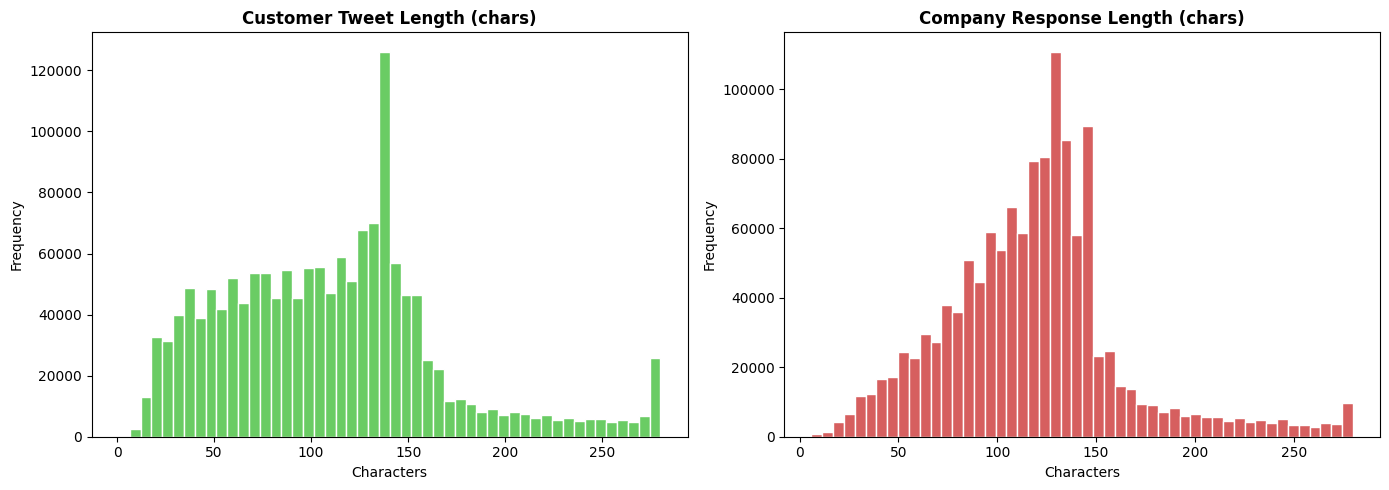

In [9]:
df['text_length'] = df['text'].fillna('').str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette('muted')

df[df['inbound']]['text_length'].clip(upper=280).plot(
    kind='hist', bins=50, ax=axes[0],
    color=colors[2], edgecolor='white'
)
axes[0].set_title('Customer Tweet Length (chars)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Characters')

df[~df['inbound']]['text_length'].clip(upper=280).plot(
    kind='hist', bins=50, ax=axes[1],
    color=colors[3], edgecolor='white'
)
axes[1].set_title('Company Response Length (chars)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Characters')

plt.tight_layout()
plt.show()

In [19]:
# function to label intent
def label_intent(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 'other'
    t = text.lower()
    if any(kw in t for kw in COMPLAINT_KW):
        return 'complaint'
    if '?' in text:
        return 'question'
    if any(kw in t for kw in POSITIVE_KW):
        return 'positive'
    return 'other'

In [21]:
df['intent'] = df['text'].apply(label_intent)

intent_counts = df['intent'].value_counts()
intent_pct = df['intent'].value_counts(normalize=True).mul(100).round(1)

intent_summary = pd.DataFrame({'count': intent_counts, 'pct': intent_pct})
print(intent_summary.to_string())

             count   pct
intent                  
other      1559381  55.5
question    605448  21.5
complaint   362772  12.9
positive    284173  10.1


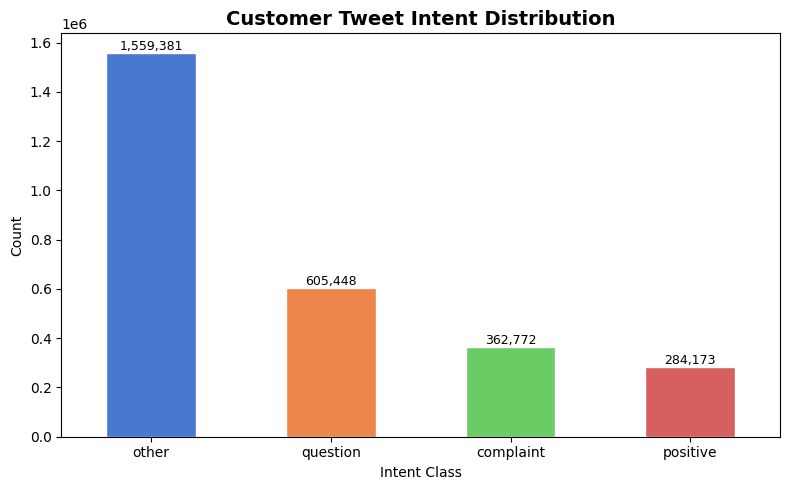

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
intent_counts.plot(
    kind='bar', ax=ax,
    color=sns.color_palette('muted')[:4],
    edgecolor='white'
)
ax.set_title('Customer Tweet Intent Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Intent Class')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### Data Cleaning & Preprocessing

In [15]:
# initialize objects
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [16]:
# function to clean text
def preprocess_text(text):
    # step 1: convert to lowercase
    text = text.lower()

    # step 2: remove URLs if present
    text = re.sub(r'http\S+', '', text)

    # step 3: remove mentions
    text = re.sub(r'@\w+', '', text)

    # step 4: remove special characters
    text = re.sub(r'[^a-zA-Z ]', '', text)

    # step 5: tokenization
    tokens = word_tokenize(text)

    # step 6: remove stopwords
    tokens = [
        word
        for word in tokens
        if word not in stop_words
    ]

    # step 7: lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [17]:
# apply preprocessing to generate cleaned text column
df['clean_text'] = df['text'].astype(str).apply(preprocess_text)

df[['text','clean_text']].head()

,text,clean_text
0,@115712 I understand. I would like to assist y...,understand would like assist would need get pr...
1,@sprintcare and how do you propose we do that,propose
2,@sprintcare I have sent several private messag...,sent several private message one responding usual
3,@115712 Please send us a Private Message so th...,please send u private message assist click mes...
4,@sprintcare I did.,


In [23]:
# function to assign categories
def assign_category(text):
    text = text.lower()

    if "refund" in text:
        return "Refund"

    elif "payment" in text:
        return "Billing"

    elif "login" in text:
        return "Account"

    elif "password" in text:
        return "Account"

    elif "cancel" in text:
        return "Cancellation"

    else:
        return "General"

In [24]:
df['category'] = df['text'].astype(str).apply(assign_category)
print(df['category'].value_counts())

category
General         2709918
Cancellation      39262
Refund            37169
Billing           13770
Account           11655
Name: count, dtype: int64


In [25]:
# feature extraction
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['clean_text'])

y = df['category']

In [26]:
# split into train, test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
# train logistic regression
classifier = LogisticRegression()

classifier.fit(X_train, y_train)

LogisticRegression()

In [28]:
# evaluate the classifier
predictions = classifier.predict(X_test)

print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

     Account       0.99      0.95      0.97      2268
     Billing       0.99      0.96      0.98      2780
Cancellation       0.99      0.96      0.97      7793
     General       1.00      1.00      1.00    541967
      Refund       1.00      0.96      0.98      7547

    accuracy                           1.00    562355
   macro avg       1.00      0.97      0.98    562355
weighted avg       1.00      1.00      1.00    562355



In [31]:
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - ------------------------------------- 0.5/12.8 MB 509.0 kB/s eta 0:00:25
     - ------------------------------------- 0.5/12.8 MB 509.0 kB/s eta 0:00:25
     -- ------------------------------------ 0.8/12.8 MB 532.8 kB/s eta 0:00:23
     -- ------------------------------------ 0.8/12.8 MB 532.8 kB/s eta 0:00:23
     --- ----------------------------------- 1.0/12.8 MB 578.7 kB/s eta 0:00:21
     --- ----------------------------------- 1.0/12.8 MB 578.7 kB/s eta 0:00:21
     --- ----------------------------------- 1.3/12.8 MB 610.0 kB/s eta 0:00:19
     ---


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# load spaCy
nlp = spacy.load("en_core_web_sm")

In [33]:
# function to extract entities
def extract_entities(text):
    doc = nlp(text)
    entities = []

    for ent in doc.ents:
        entities.append(
            (ent.text, ent.label_)
        )

    return entities

In [37]:
# sample entity testing
print(extract_entities("My Microsoft Surface Pro stopped working."))

[('Microsoft Surface Pro', 'ORG')]


In [35]:
# pos tagging
def pos_tags(text):
    doc = nlp(text)
    tags = []

    for token in doc:
        tags.append(
            (token.text, token.pos_)
        )

    return tags

In [38]:
# sample pos tagging
print(pos_tags("My laptop stopped working yesterday"))

[('My', 'PRON'), ('laptop', 'NOUN'), ('stopped', 'VERB'), ('working', 'VERB'), ('yesterday', 'NOUN')]


In [39]:
# we will use vader from nltk for sentiment analysis
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...


True

In [41]:
# initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [42]:
# sentiment extractor function
def get_sentiment(text):
    score = sia.polarity_scores(text)
    compound = score['compound']

    if compound >= 0.05:
        return "Positive"
    elif compound <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [43]:
df['sentiment'] = df['text'].astype(str).apply(get_sentiment)

print(df['sentiment'].value_counts())

sentiment
Positive    1427287
Neutral      724467
Negative     660020
Name: count, dtype: int64


In [57]:
from sentence_transformers import SentenceTransformer

ValueError: Your currently installed version of Keras is Keras 3, but this is not yet supported in Transformers. Please install the backwards-compatible tf-keras package with `pip install tf-keras`.

In [49]:
# sentence embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

NameError: name 'SentenceTransformer' is not defined

### Techniques we will cover
#### Basic Techniques
- Text Preprocessing
- TF-IDF Classification
- NER
- POS Tagging
- Sentiment Analysis
#### Advanced Techniques
- LLM Response Generation
- RAG
- Prompt Engineering
- Agentic Design
- Automated Escalation